  Preparing metadata (setup.py) ... done
Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

SOM training completed.
Quantization Error: 0.21491607374759064


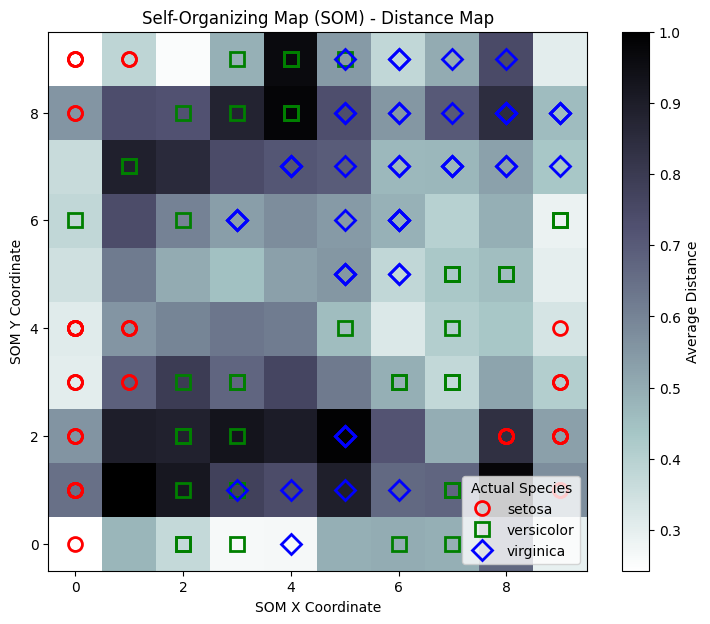


BMU Coordinates of First 10 Samples:
Sample 1: (np.int64(0), np.int64(4))
Sample 2: (np.int64(8), np.int64(2))
Sample 3: (np.int64(9), np.int64(2))
Sample 4: (np.int64(9), np.int64(2))
Sample 5: (np.int64(0), np.int64(2))
Sample 6: (np.int64(0), np.int64(8))
Sample 7: (np.int64(0), np.int64(3))
Sample 8: (np.int64(0), np.int64(4))
Sample 9: (np.int64(9), np.int64(3))
Sample 10: (np.int64(8), np.int64(2))


In [1]:
# Step 1: Install MiniSom
!pip install minisom -q

# Step 2: Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from minisom import MiniSom
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Step 3: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Create the SOM model
som = MiniSom(
    x=10,
    y=10,
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

# Step 6: Initialize and train the SOM
som.random_weights_init(X_scaled)

som.train_random(
    X_scaled,
    num_iteration=1000
)

print("\nSOM training completed.")

# Step 7: Calculate quantization error
quantization_error = som.quantization_error(X_scaled)
print("Quantization Error:", quantization_error)

# Step 8: Plot the SOM distance map
plt.figure(figsize=(9, 7))

distance_map = som.distance_map()

plt.imshow(
    distance_map,
    cmap="bone_r",
    origin="lower"
)

plt.colorbar(label="Average Distance")
plt.title("Self-Organizing Map (SOM) - Distance Map")

# Step 9: Display species on the SOM grid
markers = ["o", "s", "D"]
colors = ["red", "green", "blue"]

for i, sample in enumerate(X_scaled):
    # Find the Best Matching Unit (BMU)
    winner = som.winner(sample)

    # Plot the sample on its BMU
    plt.plot(
        winner[0],
        winner[1],
        markers[y[i]],
        markerfacecolor="None",
        markeredgecolor=colors[y[i]],
        markersize=10,
        markeredgewidth=2
    )

# Create legend
for i, species in enumerate(iris.target_names):
    plt.plot(
        [],
        [],
        markers[i],
        markerfacecolor="None",
        markeredgecolor=colors[i],
        label=species,
        markersize=10,
        markeredgewidth=2
    )

plt.legend(title="Actual Species")
plt.xlabel("SOM X Coordinate")
plt.ylabel("SOM Y Coordinate")
plt.grid(False)
plt.show()

# Step 10: Display the BMU coordinates of first 10 samples
print("\nBMU Coordinates of First 10 Samples:")

for i in range(10):
    print(
        f"Sample {i + 1}: {som.winner(X_scaled[i])}"
    )